# 🚗 Car Price Prediction Using Linear Regression

## 1. 📌 Project Overview

### Project Approach

## 2. 🎯 Problem Statement

## 3. 🎯 Objective

## 4. 📊 Dataset Information

## 5. 📚 Import Libraries

In [68]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error , mean_absolute_percentage_error , root_mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [69]:
import warnings
warnings.filterwarnings('ignore')

## 6. 📂 Data Loading

In [70]:
cp = pd.read_csv(r"D:\Downloads\car_price.csv")

In [71]:
cp.shape

(205, 26)

## 7. 🔍 Data Understanding

In [72]:
cp.head(2)

,symboling,normalized_losses,Fuel_type,make,num_of_doors,aspiration,wheel_base,engine_location,drive_wheels,body_style,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,gas,std,two,convertible,rwd,front,88.6,alfa-romero,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,gas,std,two,convertible,rwd,front,88.6,alfa-romero,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500


In [73]:
cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    object 
 2   Fuel_type          205 non-null    object 
 3   make               205 non-null    object 
 4   num_of_doors       205 non-null    object 
 5   aspiration         205 non-null    object 
 6   wheel_base         205 non-null    object 
 7   engine_location    205 non-null    object 
 8   drive_wheels       205 non-null    float64
 9   body_style         205 non-null    object 
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_of_cylinders   205 non-null    object 
 16  engine_size        205 non

In [74]:
cp.describe()

,symboling,drive_wheels,length,width,height,curb_weight,engine_size,compression_ratio,city_mpg,highway_mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [75]:
cp.columns

Index(['symboling', 'normalized_losses', 'Fuel_type', 'make', 'num_of_doors',
       'aspiration', 'wheel_base', 'engine_location', 'drive_wheels',
       'body_style', 'length', 'width', 'height', 'curb_weight', 'engine_type',
       'num_of_cylinders', 'engine_size', 'fuel_system', 'bore', 'stroke',
       'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg',
       'highway_mpg', 'price'],
      dtype='object')

## 8. 🧹 Data Cleaning & Preprocessing

In [76]:
cp = cp.replace({'?': np.nan})

In [77]:
cp.select_dtypes(include ='object').columns

Index(['normalized_losses', 'Fuel_type', 'make', 'num_of_doors', 'aspiration',
       'wheel_base', 'engine_location', 'body_style', 'engine_type',
       'num_of_cylinders', 'fuel_system', 'bore', 'stroke', 'horsepower',
       'peak_rpm', 'price'],
      dtype='object')

In [78]:
# cp.num_of_doors.value_counts()
# cp.num_of_cylinders.value_counts()

In [79]:
cp.num_of_doors = cp.num_of_doors.replace({'four':4 , 'two':2})
cp.num_of_cylinders = cp.num_of_cylinders.replace({'four':4 , 'six':6 , 'five':5 , 'eight':8 , 'two':2 , 'three':3 , 'twelve':12})

In [80]:
cp.normalized_losses = cp.normalized_losses.astype(float)                            
cp.bore = cp.bore.astype(float)
cp.stroke = cp.stroke.astype(float)
cp.horsepower = cp.horsepower.astype(float)
cp.peak_rpm = cp.peak_rpm.astype(float)
cp.price = cp.price.astype(float)

In [81]:
cp.select_dtypes(include ='object').columns

Index(['Fuel_type', 'make', 'aspiration', 'wheel_base', 'engine_location',
       'body_style', 'engine_type', 'fuel_system'],
      dtype='object')

### Check Missing Values

In [82]:
cp.isnull().sum()[cp.isnull().sum() > 0] * 100 / cp.shape[0]

normalized_losses    20.00000
num_of_doors          0.97561
bore                  1.95122
stroke                1.95122
horsepower            0.97561
peak_rpm              0.97561
price                 1.95122
dtype: float64

In [83]:
cp.normalized_losses = cp.normalized_losses.fillna(cp.normalized_losses.mean())
cp.num_of_doors = cp.num_of_doors.fillna(4.0)
cp.bore = cp.bore.fillna(cp.bore.mean())
cp.stroke = cp.stroke.fillna(cp.stroke.mean())
cp.horsepower = cp.horsepower.fillna(cp.horsepower.mean())
cp.peak_rpm = cp.peak_rpm.fillna(cp.peak_rpm.mean())
cp.price = cp.price.fillna(cp.price.mean())

In [84]:
cp.isnull().sum()[cp.isnull().sum() > 0]

Series([], dtype: int64)

### Categorical Encoding

In [85]:
le = LabelEncoder() 

In [86]:
cp[cp.select_dtypes(include='object').columns] = cp[cp.select_dtypes(include='object').columns].apply(le.fit_transform)

In [87]:
cp.select_dtypes(include ='object').columns

Index([], dtype='object')

## 9. 📈 Exploratory Data Analysis

### Distribution of Car Prices

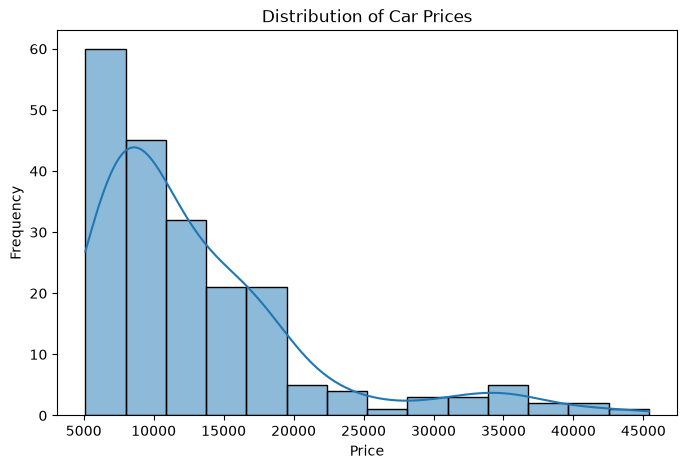

In [88]:
plt.figure(figsize=(8,5)) 
sns.histplot(cp["price"], kde=True) 
plt.title("Distribution of Car Prices") 
plt.xlabel("Price") 
plt.ylabel("Frequency") 
plt.show()

### Correlation Heatmap

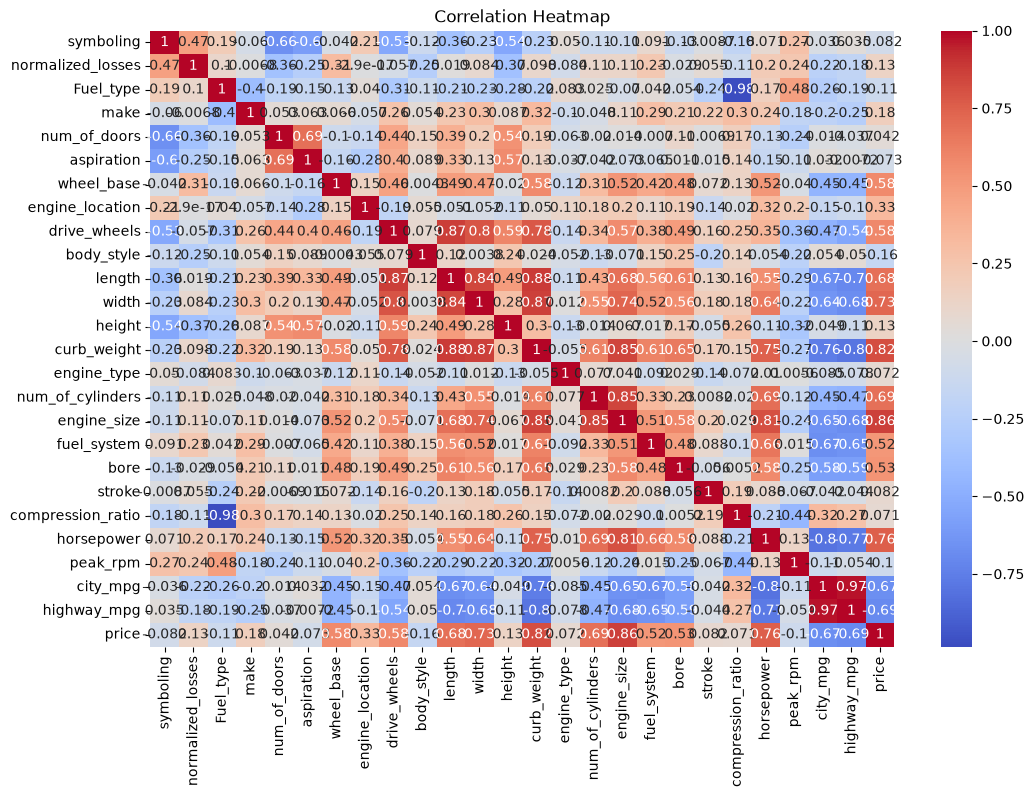

In [89]:
plt.figure(figsize=(12,8)) 
sns.heatmap( cp.corr(numeric_only=True), annot=True, cmap="coolwarm" ) 
plt.title("Correlation Heatmap") 
plt.show()

### Feature vs Price Analysis

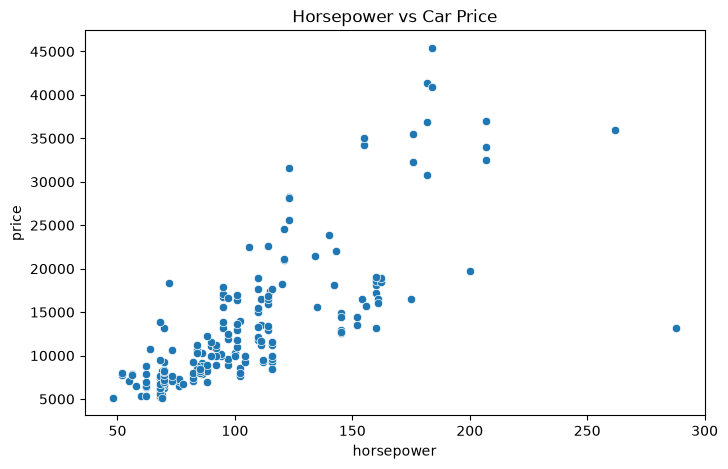

In [93]:
plt.figure(figsize=(8,5)) 
sns.scatterplot( data=cp, x="horsepower", y="price" ) 
plt.title("Horsepower vs Car Price") 
plt.show()

## 10. ⚙️ Feature Engineering

In [94]:
cp_x = cp.drop("price", axis=1) 
cp_y = cp["price"]

## 11. 🎯 Feature Selection

In [95]:
correlation = cp.corr(numeric_only=True)["price"].sort_values( ascending=False )

In [96]:
correlation

price                1.000000
engine_size          0.861752
curb_weight          0.820825
horsepower           0.757917
width                0.728699
num_of_cylinders     0.687770
length               0.682986
drive_wheels         0.583168
wheel_base           0.576866
bore                 0.532300
fuel_system          0.516533
engine_location      0.331013
make                 0.177285
height               0.134388
normalized_losses    0.133999
stroke               0.082095
engine_type          0.071535
compression_ratio    0.070990
num_of_doors         0.041945
aspiration          -0.072677
symboling           -0.082201
peak_rpm            -0.100854
Fuel_type           -0.110207
body_style          -0.161471
city_mpg            -0.667449
highway_mpg         -0.690526
Name: price, dtype: float64

In [97]:
selected_features = correlation[ correlation.abs() > 0.1 ].index

In [98]:
selected_features = selected_features.drop("price")

In [99]:
cp_selected_x = cp[selected_features]

## 12. ✂️ Train-Test Split

In [100]:
cp_train_x, cp_test_x, cp_train_y, cp_test_y = train_test_split(cp_x, cp_y, test_size=0.20, random_state=42 )

In [101]:
print("Training data:", cp_train_x.shape) 
print("Testing data:", cp_test_x.shape)

Training data: (164, 25)
Testing data: (41, 25)


## 13. 🤖 Model 1 — Linear Regression Using All Features

In [102]:
model1 = LinearRegression()

model1.fit(cp_train_x, cp_train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](25,)","[ 116.23, 2.58,15545.43,..., 1.6 , 28.56, -122.33]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](25,)","['symboling','normalized_losses','Fuel_type',...,'peak_rpm','city_mpg', 'highway_mpg']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6.64e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,25
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,25


In [103]:
model1_train_pred = model1.predict(cp_train_x) 
model1_test_pred = model1.predict(cp_test_x)

## 14. 📏 Model 1 Evaluation

### Calculate Training Metrics

In [104]:
# R²
R_squ_train1 = model1.score(cp_train_x , cp_train_y)

# MSE
mse_train1 = mean_squared_error(cp_train_y, pred_train_cp)

# RMSE
rmse_train1 = np.sqrt(mse_train1)

# MAPE
mape_train1 = mean_absolute_percentage_error(cp_train_y,pred_train_cp) * 100

print("Training R²:", R_squ_train1)
print("Training MSE:", mse_train1)
print("Training RMSE:", rmse_train1)
print("Training MAPE:", mape_train1)

Training R²: 0.8939330123632364
Training MSE: 107175436.4536625
Training RMSE: 10352.55700074443
Training MAPE: 66.55290425520121


### Calculate Testing Metrics

In [105]:
# R²
R_squ_test1 = model1.score(cp_test_x , cp_test_y)

# MSE
mse_test1 = mean_squared_error(cp_test_y, pred_test_cp)

# RMSE
rmse_test1 = np.sqrt(mse_test1)

# MAPE
mape_test1 = mean_absolute_percentage_error(cp_test_y,pred_test_cp) * 100

print("Testing R²:", R_squ_test1)
print("Testing MSE:", mse_test1)
print("Testing RMSE:", rmse_test1)
print("Testing MAPE:", mape_test1)

Testing R²: 0.8192518460824334
Testing MSE: 103000568.01348285
Testing RMSE: 10148.919549069391
Testing MAPE: 60.08500726786774


### Calculate Adjusted R²

In [106]:
N = cp_train_x.shape[0]
K = cp_train_x.shape[1]
Adj_Rsq_train1 = 1 - (1-R_squ_train1) * (N-1) / (N-K-1) 
print(Adj_Rsq_train1)

0.8747179783710691


In [107]:
N = cp_test_x.shape[0]
K = cp_test_x.shape[1]
Adj_Rsq_test1 = 1 - (1-R_squ_test1) * (N-1) / (N-K-1) 
print(Adj_Rsq_test1)

0.5180049228864891


### Comparison Table

In [108]:
model1_results = pd.DataFrame({
    "Metric": ["R²","Adjusted R²","MSE","RMSE","MAPE"],
    
    "Training": [R_squ_train1,Adj_Rsq_train1,mse_train1,rmse_train1,mape_train1],
    
    "Testing": [R_squ_test1,Adj_Rsq_test1,mse_test1,rmse_test1,mape_test1]
})

In [109]:
model1_results

,Metric,Training,Testing
0,R²,8.939330e-01,8.192518e-01
1,Adjusted R²,8.747180e-01,5.180049e-01
2,MSE,1.071754e+08,1.030006e+08
3,RMSE,1.035256e+04,1.014892e+04
4,MAPE,6.655290e+01,6.008501e+01


## 15. 🔎 Model 2 — Linear Regression with Selected Features

### Train-Test Split

In [110]:
cp_train_x2, cp_test_x2, cp_train_y2, cp_test_y2 = train_test_split( cp_selected_x, cp_y, test_size=0.20, random_state=42 )

### Model Building

In [111]:
model2 = LinearRegression()

In [112]:
model2.fit(cp_train_x2, cp_train_y2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](19,)","[ 107.31, 2.05, -42.17,...,-130.21, 34.25,-184.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](19,)","['engine_size','curb_weight','horsepower',...,'body_style','city_mpg', 'highway_mpg']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.535e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,19


In [113]:
model2_train_pred = model2.predict(cp_train_x2) 
model2_test_pred = model2.predict(cp_test_x2)

## 16. 📏 Model 2 Evaluation

### Training Performance

In [114]:
R_squ_train2= model2.score(cp_train_x2 , cp_train_y2) 
mse_train_2 = mean_squared_error( cp_train_y2, model2_train_pred ) 
rmse_train_2 = np.sqrt(mse_train_2) 
mape_train_2 = mean_absolute_percentage_error( cp_train_y2, model2_train_pred )

print("Training R²:", R_squ_train2) 
print("Training MSE:", mse_train_2) 
print("Training RMSE:", rmse_train_2) 
print("Training MAPE:", mape_train_2)

Training R²: 0.86890664303294
Training MSE: 7538244.792052644
Training RMSE: 2745.586420430551
Training MAPE: 0.16627481055423562


### Test Performance

In [115]:
R_squ_test2= model2.score(cp_test_x2 , cp_test_y2)
mse_test_2 = mean_squared_error( cp_test_y2, model2_test_pred ) 
rmse_test_2 = np.sqrt(mse_test_2) 
mape_test_2 = mean_absolute_percentage_error( cp_test_y2, model2_test_pred ) 

print("Test R²:", R_squ_test2) 
print("Test MSE:", mse_test_2) 
print("Test RMSE:", rmse_test_2) 
print("Test MAPE:", mape_test_2)

Test R²: 0.8128277066074026
Test MSE: 14594212.226169737
Test RMSE: 3820.2371950141705
Test MAPE: 0.22269196357916898


## 17. 🏆 Model Comparison

In [117]:
comparison = pd.DataFrame({
    "Model": [ "Model 1 - All Features", 
               "Model 2 - Selected Features" ], 
    "Test R2": [ R_squ_test1, R_squ_test2], 
    "Test RMSE": [ rmse_test1, rmse_test_2 ], 
    "Test MAPE": [ mape_test1, mape_test_2 ] })

In [118]:
comparison

,Model,Test R2,Test RMSE,Test MAPE
0,Model 1 - All Features,0.819252,10148.919549,60.085007
1,Model 2 - Selected Features,0.812828,3820.237195,0.222692


### Visual Comparison

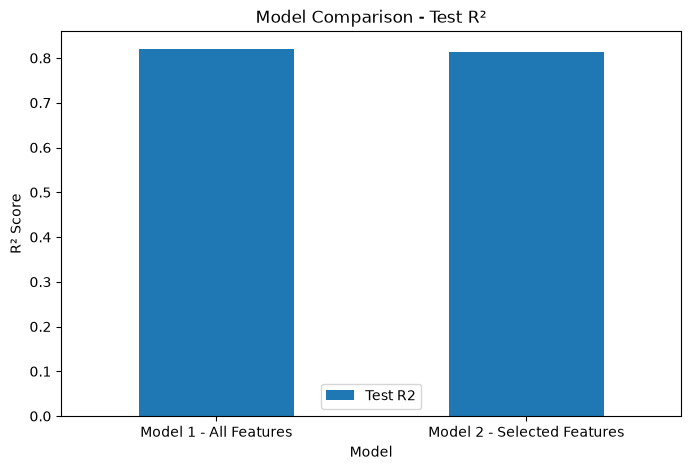

In [119]:
comparison.set_index("Model")[["Test R2"]].plot( kind="bar", figsize=(8,5) )
plt.title("Model Comparison - Test R²") 
plt.ylabel("R² Score") 
plt.xticks(rotation=0) 
plt.show()

## 18. 📉 Residual Analysis

In [120]:
act_pred = pd.DataFrame()
act_pred['Actual'] = cp_train_y
act_pred['pred'] = pred_train_cp
act_pred['error'] = act_pred['Actual'] - act_pred['pred']
act_pred.head(2)

,Actual,pred,error
66,18344.0,7494.011829,10849.988171
111,15580.0,12293.450135,3286.549865


In [121]:
act_pred.error.mean() 

np.float64(68.09598349714707)

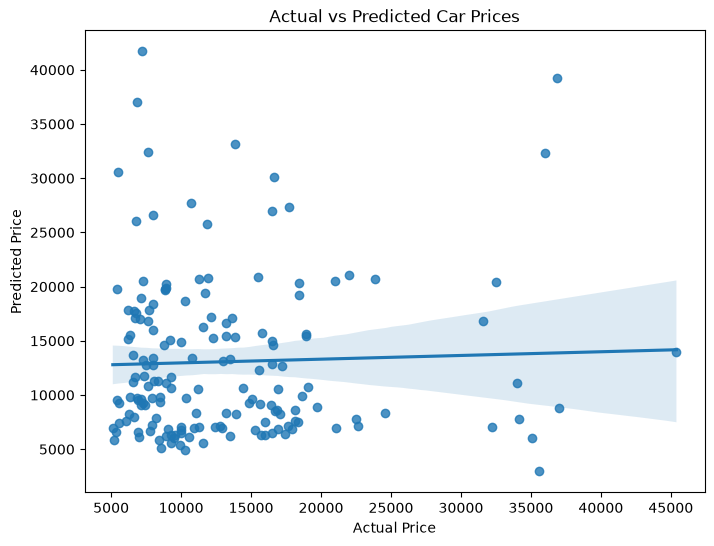

In [122]:
plt.figure(figsize=(8,6))

sns.regplot(x='Actual',y='pred',data=act_pred)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

In [123]:
residuals = cp_test_y - pred_test_cp

### Residual Distribution

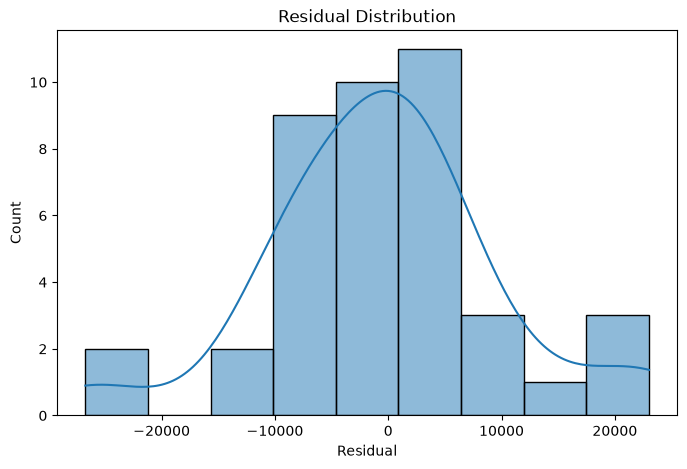

In [124]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()

### Residual Boxplot

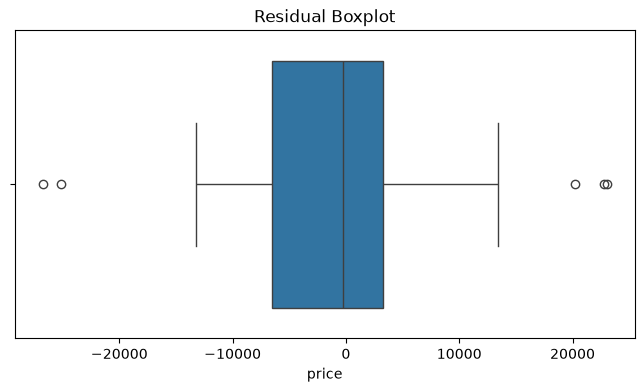

In [126]:
plt.figure(figsize=(8,4)) 
sns.boxplot(x=residuals) 
plt.title("Residual Boxplot") 
plt.show()

### Actual vs Predicted Values

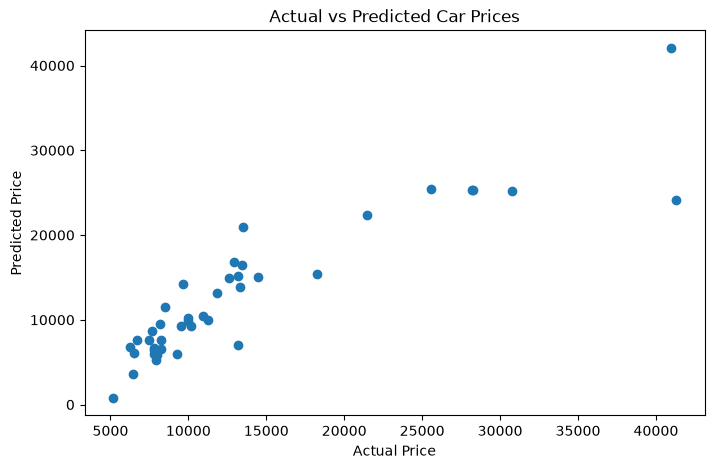

In [127]:
plt.figure(figsize=(8,5)) 
plt.scatter(cp_test_y, model1_test_pred) 
plt.xlabel("Actual Price") 
plt.ylabel("Predicted Price") 
plt.title("Actual vs Predicted Car Prices") 
plt.show()

## 19. 💡 Key Insights

## 20. ✅ Final Conclusion